In [24]:
import json
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'

In [25]:
# Find subfolders in evals/manuscripts/*/v1/ that contain all 4 JSON files
base_path = "manuscripts"
manuscript_dirs = []
for manuscript_id in os.listdir(base_path):
    v1_path = os.path.join(base_path, manuscript_id, "v1")
    if not os.path.isdir(v1_path):
        continue
    required_files = ["eval_llm.json", "eval_peer.json", "cmp.json", "claims.json"]
    all_present = all(os.path.exists(os.path.join(v1_path, fname)) for fname in required_files)
    if all_present:
        manuscript_dirs.append((manuscript_id, v1_path))

# Will concatenate all dfs from all manuscripts
dfs_llm = []
dfs_peer = []
dfs_cmp = []
dfs_claims = []
for manuscript_id, v1_path in manuscript_dirs:
    with open(os.path.join(v1_path, "eval_llm.json"), "r") as f:
        eval_llm = json.load(f)
    with open(os.path.join(v1_path, "eval_peer.json"), "r") as f:
        eval_peer = json.load(f)
    with open(os.path.join(v1_path, "cmp.json"), "r") as f:
        cmp = json.load(f)
    with open(os.path.join(v1_path, "claims.json"), "r") as f:
        claims = json.load(f)
    df_llm = pd.DataFrame(eval_llm)
    df_peer = pd.DataFrame(eval_peer)
    df_cmp = pd.DataFrame(cmp)
    df_claims = pd.DataFrame(claims)
    # Add manuscript_id as a column for possible stratification
    for df in (df_llm, df_peer, df_cmp, df_claims):
        df["manuscript_id"] = manuscript_id
    dfs_llm.append(df_llm)
    dfs_peer.append(df_peer)
    dfs_cmp.append(df_cmp)
    dfs_claims.append(df_claims)

# Concatenate
df_llm = pd.concat(dfs_llm, ignore_index=True)
df_peer = pd.concat(dfs_peer, ignore_index=True)
df_cmp = pd.concat(dfs_cmp, ignore_index=True)
df_claims = pd.concat(dfs_claims, ignore_index=True)

In [26]:
df_cmp

,openeval_result_id,peer_result_id,openeval_status,peer_status,agreement_status,comparison,n_openeval,n_peer,n_itx,manuscript_id
0,R12,R4,SUPPORTED,SUPPORTED,agree,Perfect agreement on short-term plasticity cla...,13.0,13.0,13,elife-99711
1,R13,R6,SUPPORTED,SUPPORTED,agree,Perfect agreement on frequency-dependent filte...,8.0,8.0,8,elife-99711
2,R11,R3,SUPPORTED,SUPPORTED,agree,Strong agreement on anatomical evidence for sp...,15.0,14.0,14,elife-99711
3,R9,R2,SUPPORTED,SUPPORTED,agree,Strong agreement on minimal stimulation data (...,8.0,10.0,8,elife-99711
4,R10,R2,SUPPORTED,SUPPORTED,agree,Agreement on asynchronous release experiments ...,2.0,10.0,2,elife-99711
...,...,...,...,...,...,...,...,...,...,...
2919,R14,None,SUPPORTED,None,disjoint,"OpenEval evaluates claims C67, C84 (non-sequen...",2.0,NaN,0,elife-00173
2920,R15,None,SUPPORTED,None,disjoint,OpenEval evaluates claims C86-C90 (limitations...,5.0,NaN,0,elife-00173
2921,R16,None,UNCERTAIN,None,disjoint,OpenEval rates claim C93 (evolutionary implica...,1.0,NaN,0,elife-00173
2922,R17,None,SUPPORTED,None,disjoint,"OpenEval evaluates claims C1, C8-C18, C91 (est...",13.0,NaN,0,elife-00173


In [27]:
df_cmp["peer_status"] = df_cmp["peer_status"].fillna("Unknown").replace("Unknown", "Not reviewed")
df_cmp["openeval_status"] = df_cmp["openeval_status"].fillna("Unknown").replace("Unknown", "Not reviewed")

ordered_statuses = ["Supported", "Uncertain", "Unsupported", "Not reviewed"]

df_cmp["peer_status"] = df_cmp["peer_status"].astype(str).str.capitalize()
df_cmp["openeval_status"] = df_cmp["openeval_status"].astype(str).str.capitalize()
df_cmp["peer_status"] = pd.Categorical(df_cmp["peer_status"], categories=ordered_statuses, ordered=True)
df_cmp["openeval_status"] = pd.Categorical(df_cmp["openeval_status"], categories=ordered_statuses, ordered=True)

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_68347/694637313.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_agree.set_yticklabels([str(int(x)) for x in ax_agree.get_yticks()], fontsize=fontsize)


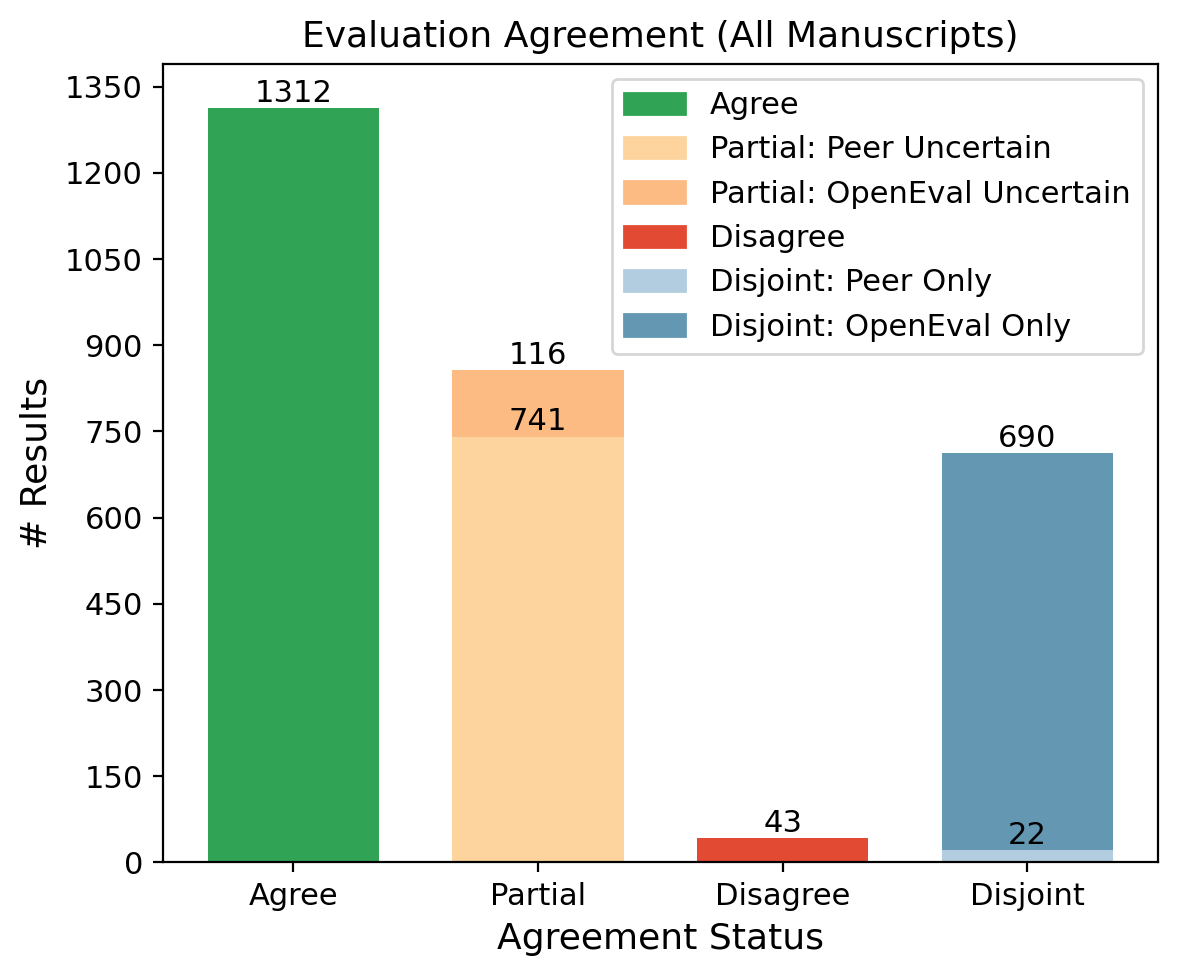

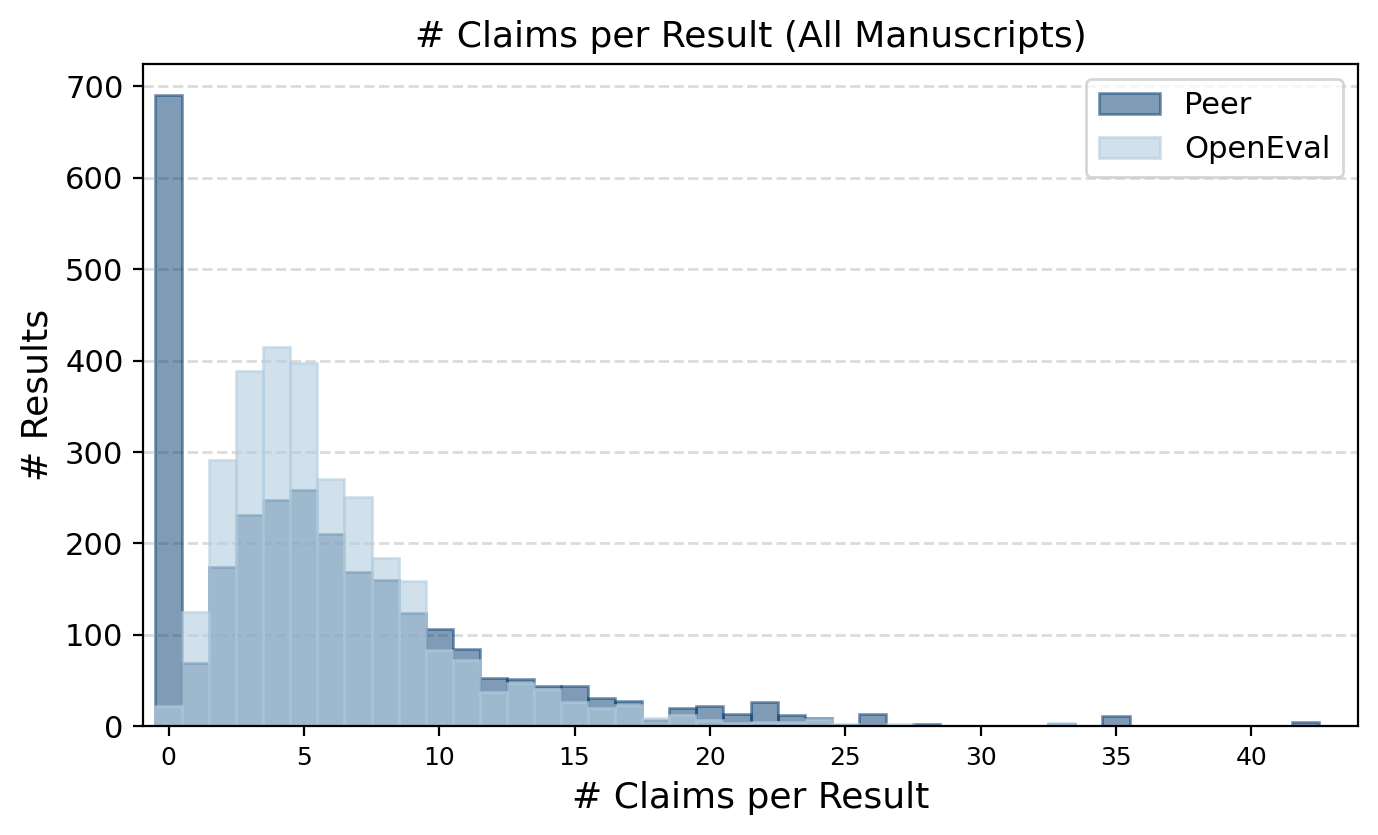

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_68347/694637313.py:290: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(xlim)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_68347/694637313.py:291: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim)
/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_68347/694637313.py:294: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


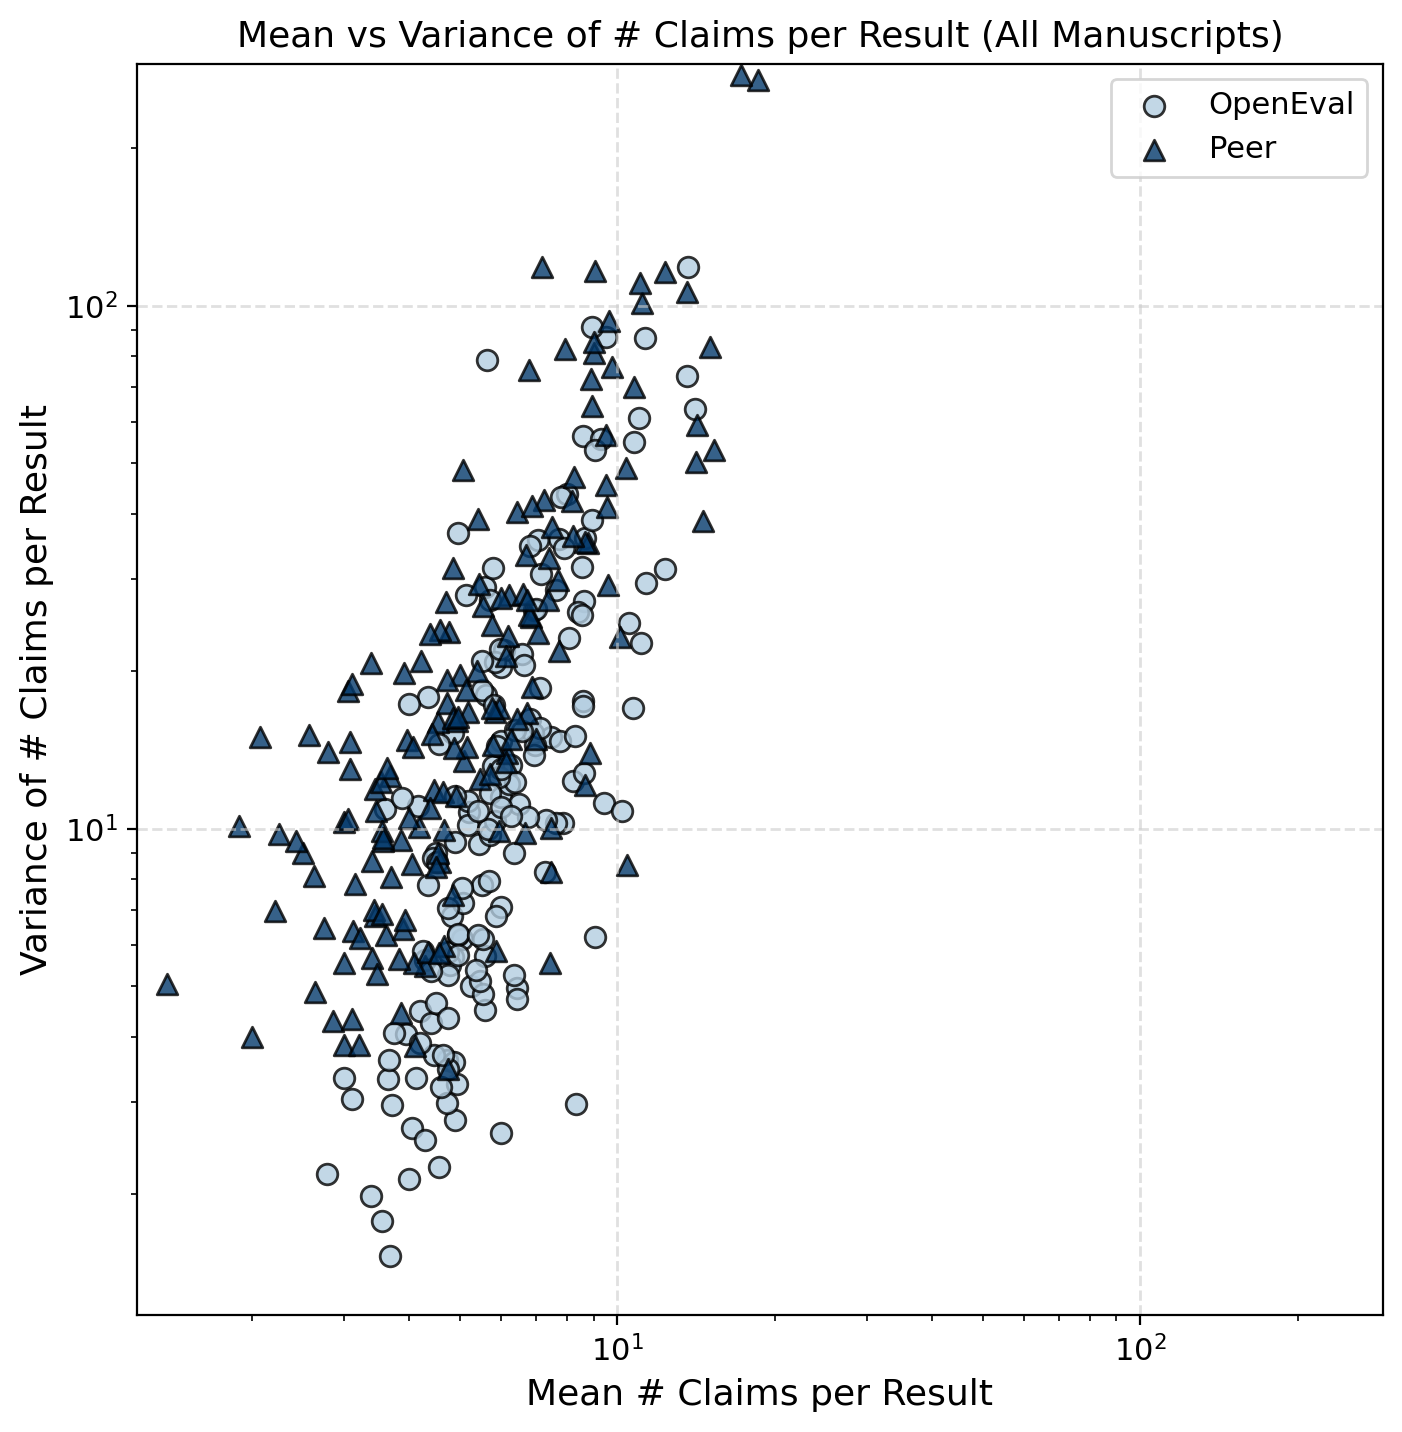

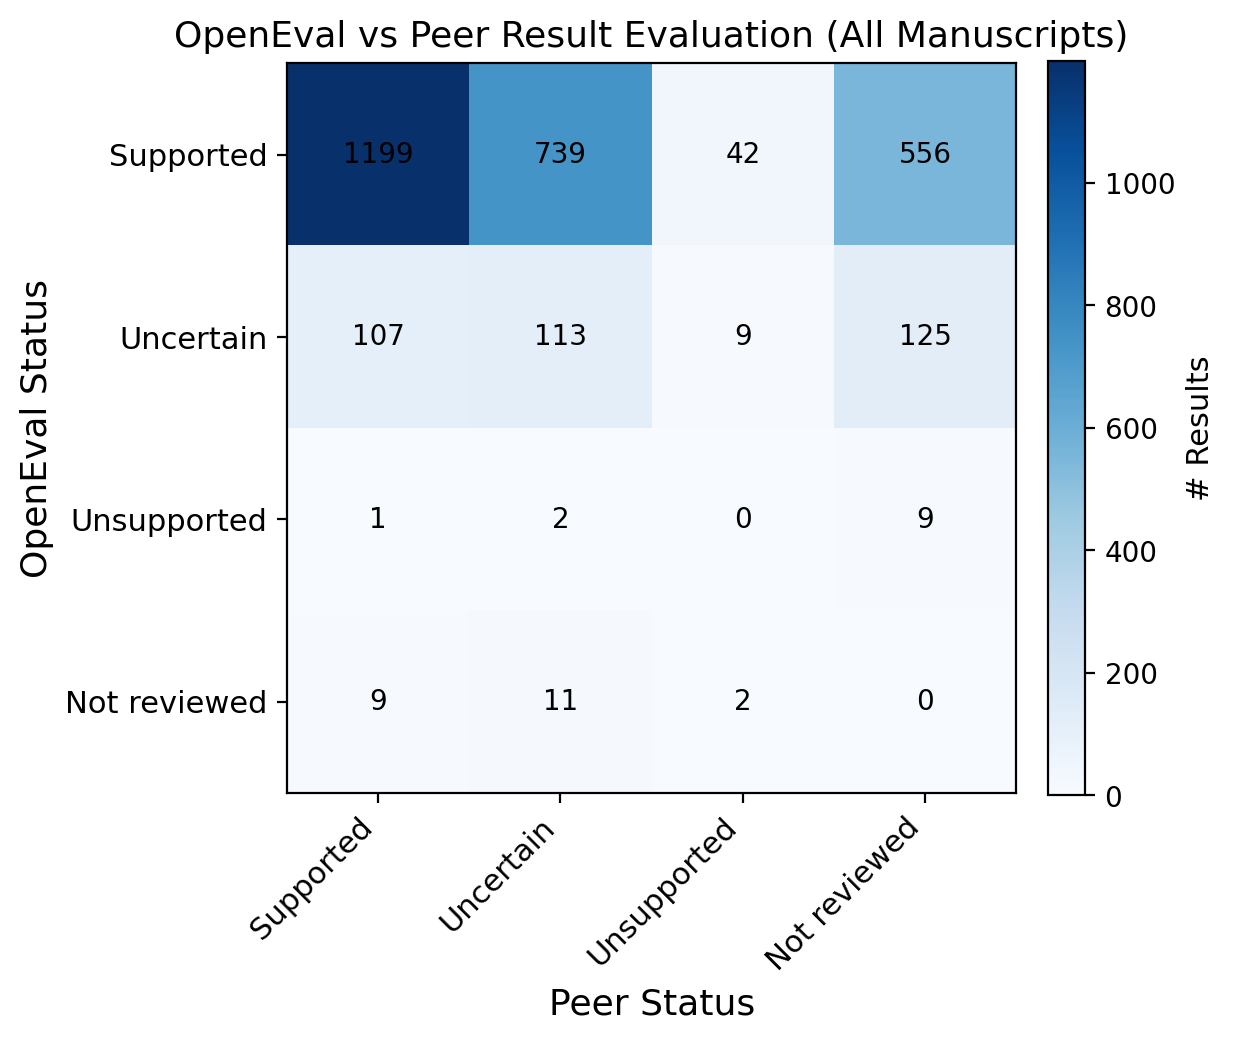

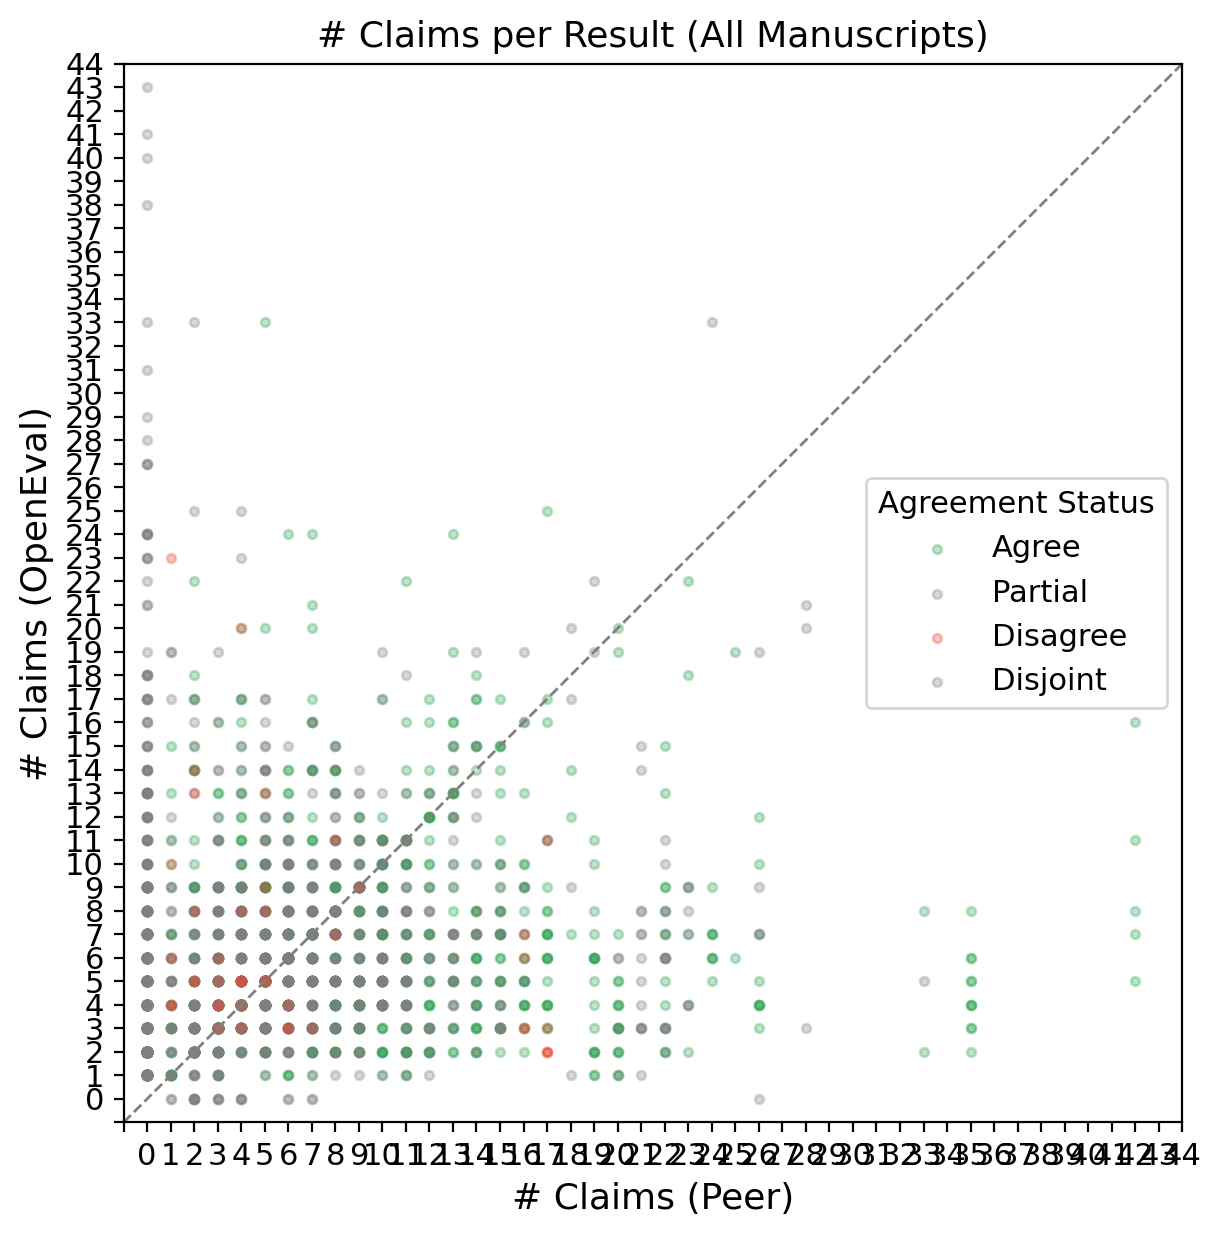

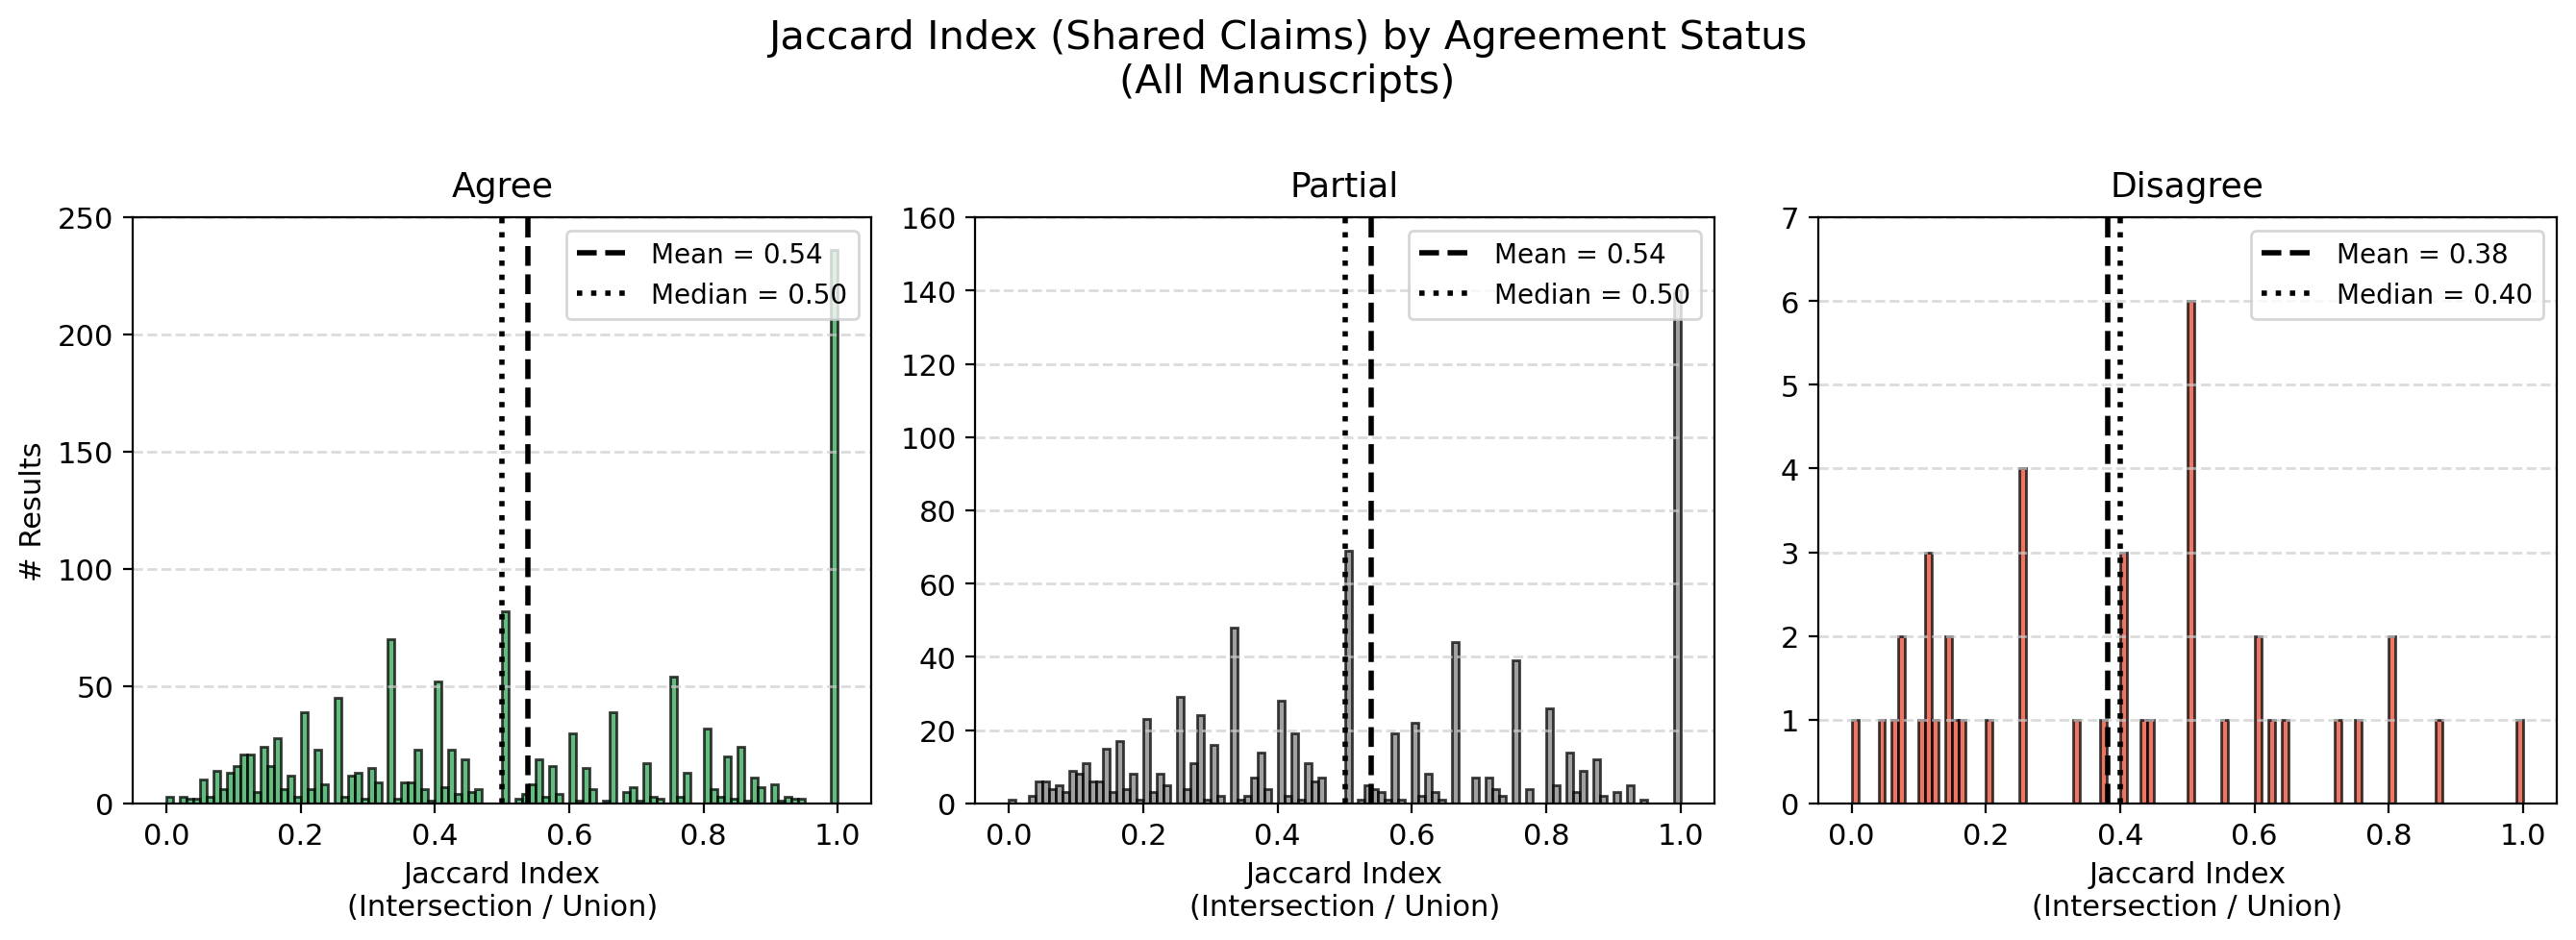


Summary statistics (all manuscripts):


,openeval_result_id,n_openeval,n_peer,n_itx,intersection_fraction
agreement_status,,,,,
Agree,1312,6.22,8.24,4.27,0.54
Partial,857,6.38,7.13,3.99,0.54
Disagree,43,6.58,6.56,2.88,0.38
Disjoint,690,5.60,4.36,0.00,0.00


In [52]:
# --- Plotting and color configs ---
bar_color = "#6baed6"

# Updated colors for new subcategories
colors = {
    "Agree": "#31a354",
    "Partial:PeerUncertain": "#FDD49E",     # Peer Uncertain
    "Partial:OpenEvalUncertain": "#FDBB84", # OpenEval Uncertain
    "Disagree": "#e34a33",
    "Disjoint:PeerOnly": "#b3cde0",         # Disjoint, only Peer has the result
    "Disjoint:OpenEvalOnly": "#6497b1"      # Disjoint, only LLM/OpenEval has the result
}
status_colors = colors

colors_stacked = {
    "shared": "#6497b1",
    "openeval_only": "#b3cde0",
    "peer_only": "#03396c"
}
jaccard_color = "#6497b1"

fontsize = 11

# Helper: which status is "uncertain"
def partial_split(row):
    if row["agreement_status"] == "Partial":
        # Figure out whose status is Uncertain
        peer_s = str(row["peer_status"]).lower()
        open_s = str(row["openeval_status"]).lower()
        # Both being uncertain is possible but rare, split by LLM by default
        # Assume capitalization for peer/openeval statuses
        if peer_s == "uncertain":
            return "Partial:PeerUncertain"
        elif open_s == "uncertain":
            return "Partial:OpenEvalUncertain"
        else:
            return "Partial:Other"
    return None

def disjoint_split(row):
    if row["agreement_status"] == "Disjoint":
        n_peer = row.get("n_peer", np.nan)
        n_open = row.get("n_openeval", np.nan)
        # If one is 0, it's the other's only
        if pd.isna(n_peer):
            n_peer = 0
        if pd.isna(n_open):
            n_open = 0
        if (n_peer == 0 or n_peer == 0.0) and (n_open > 0):
            return "Disjoint:OpenEvalOnly"
        elif (n_open == 0 or n_open == 0.0) and (n_peer > 0):
            return "Disjoint:PeerOnly"
        # ambiguous, fallback
        elif n_peer > n_open:
            return "Disjoint:PeerOnly"
        else:
            return "Disjoint:OpenEvalOnly"
    return None

df_cmp["agreement_status"] = df_cmp["agreement_status"].astype(str).str.capitalize()

# Calculate intersection fraction (Jaccard denominator is max(n_openeval, n_peer))
df_cmp["intersection_fraction"] = df_cmp["n_itx"] / df_cmp[["n_openeval", "n_peer"]].max(axis=1)

def safe_int(s):
    return s.where(pd.notnull(s) & np.isfinite(s), 0).astype(int)

df_cmp["n_peer_int"] = safe_int(df_cmp["n_peer"])
df_cmp["n_openeval_int"] = safe_int(df_cmp["n_openeval"])

# ------ 1. Improved Stacked Bar Plot ------
# Build subcategories as described
df_cmp["agree_bar_cat"] = df_cmp["agreement_status"]

# Split 'Partial'
partial_mask = df_cmp["agreement_status"] == "Partial"
df_cmp.loc[partial_mask, "agree_bar_cat"] = df_cmp[partial_mask].apply(partial_split, axis=1)

# Split 'Disjoint' using n_peer/n_openeval
disjoint_mask = df_cmp["agreement_status"] == "Disjoint"
df_cmp.loc[disjoint_mask, "agree_bar_cat"] = df_cmp[disjoint_mask].apply(disjoint_split, axis=1)

# Only keep supported categories
stacked_bar_categories = [
    "Agree",
    "Partial:PeerUncertain", 
    "Partial:OpenEvalUncertain", 
    "Disagree", 
    "Disjoint:PeerOnly", 
    "Disjoint:OpenEvalOnly"
]

# Count for each group/subcat
from collections import OrderedDict

agree_counts = OrderedDict((cat, 0) for cat in stacked_bar_categories)
for cat, count in df_cmp["agree_bar_cat"].value_counts().items():
    if cat in agree_counts:
        agree_counts[cat] = count

# Bar stacking: x-axis has 4 groups; for 'Partial' and 'Disjoint', need bottom/top segments
bar_groups = ["Agree", "Partial", "Disagree", "Disjoint"]
# Stacks in each group:
partial_cats = ["Partial:PeerUncertain", "Partial:OpenEvalUncertain"]
disjoint_cats = ["Disjoint:PeerOnly", "Disjoint:OpenEvalOnly"]

# Build stack heights for each group
y_main = [
    agree_counts["Agree"],
    agree_counts["Partial:PeerUncertain"],
    agree_counts["Disagree"],
    agree_counts["Disjoint:PeerOnly"]
]
y_stack = [
    0, # Agree is not stacked
    agree_counts["Partial:OpenEvalUncertain"],
    0, # Disagree is not stacked
    agree_counts["Disjoint:OpenEvalOnly"]
]
bar_colors_main = [
    colors["Agree"],
    colors.get("Partial:PeerUncertain", "#ccc"),
    colors["Disagree"],
    colors.get("Disjoint:PeerOnly", "#ccc")
]
bar_colors_stack = [
    "#fff",  # Not used
    colors.get("Partial:OpenEvalUncertain", "#ccc"),
    "#fff",  # Not used
    colors.get("Disjoint:OpenEvalOnly", "#ccc")
]
bar_labels_main = ["Agree", "Peer Uncertain", "Disagree", "Peer Only"]
bar_labels_stack = ["", "OpenEval Uncertain", "", "OpenEval Only"]

fig_agree, ax_agree = plt.subplots(figsize=(6, 5))
bar_width = 0.7
bar_positions = range(len(bar_groups))

# Plot base/main bars
main_bars = ax_agree.bar(bar_positions, y_main, color=bar_colors_main, width=bar_width, label=bar_labels_main)
# Plot stacked parts
stack_bars = ax_agree.bar(bar_positions, y_stack, 
                          bottom=y_main, color=bar_colors_stack, width=bar_width, label=bar_labels_stack)

# Add category labels
for i, val in enumerate(y_main):
    if val > 0:
        ax_agree.text(i, val + 0.3, str(val), ha="center", va="bottom", fontsize=fontsize)
for i, (val_stack, val_main) in enumerate(zip(y_stack, y_main)):
    if val_stack > 0:
        ax_agree.text(i, val_main + val_stack + 0.3, str(val_stack), ha="center", va="bottom", fontsize=fontsize)

# Set x-axis ticks and labels
ax_agree.set_xticks(bar_positions)
ax_agree.set_xticklabels(bar_groups, fontsize=fontsize)

ax_agree.set_title("Evaluation Agreement (All Manuscripts)", fontsize=fontsize+2)
ax_agree.set_xlabel("Agreement Status", fontsize=fontsize+2)
ax_agree.set_ylabel("# Results", fontsize=fontsize+2)

# Remove (do not show) grid
ax_agree.grid(False)

# Set integer y axis
from matplotlib.ticker import MaxNLocator
ax_agree.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_agree.set_yticklabels([str(int(x)) for x in ax_agree.get_yticks()], fontsize=fontsize)

# Slightly increase ylim so there is space for the bar label
bar_heights = [y_main[i] + y_stack[i] for i in range(len(y_main))]
if bar_heights:
    ymax = max(bar_heights)
    ax_agree.set_ylim(top=ymax + max(1, int(0.06 * ymax)))  # add 6% or at least 1

# Build custom legend using labels (main+stacked), showing only those that appear
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=colors.get("Agree"), label="Agree"),
    mpatches.Patch(color=colors.get("Partial:PeerUncertain"), label="Partial: Peer Uncertain"),
    mpatches.Patch(color=colors.get("Partial:OpenEvalUncertain"), label="Partial: OpenEval Uncertain"),
    mpatches.Patch(color=colors.get("Disagree"), label="Disagree"),
    mpatches.Patch(color=colors.get("Disjoint:PeerOnly"), label="Disjoint: Peer Only"),
    mpatches.Patch(color=colors.get("Disjoint:OpenEvalOnly"), label="Disjoint: OpenEval Only"),
]
# Only display legend entries with counts > 0
legend_patches_present = []
for cat, patch in zip(stacked_bar_categories, legend_patches):
    if agree_counts[cat] > 0:
        legend_patches_present.append(patch)
if legend_patches_present:
    ax_agree.legend(handles=legend_patches_present, fontsize=fontsize, title_fontsize=fontsize, loc="best")

plt.tight_layout()
fig_agree.savefig("figures/eval_agreement_bar_all_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 1b. Histogram of # claims per result for LLM and Peer, excluding Disjoint ---
# Filter out 'Disjoint' agreement results (or not)
# df_cmp_no_disjoint = df_cmp[df_cmp["agreement_status"] != "Disjoint"]
df_cmp_no_disjoint = df_cmp.copy()

bins_claims = np.arange(
    0,
    max(df_cmp_no_disjoint["n_openeval_int"].max(), df_cmp_no_disjoint["n_peer_int"].max()) + 2
) - 0.5  # Center bins on integers

fig_claim_hist, ax_claim_hist = plt.subplots(figsize=(7, 4.3))
ax_claim_hist.hist(
    df_cmp_no_disjoint["n_peer_int"],
    bins=bins_claims,
    alpha=0.5,
    label="Peer",
    color=colors_stacked["peer_only"],
    edgecolor=colors_stacked["peer_only"]
)
ax_claim_hist.hist(
    df_cmp_no_disjoint["n_openeval_int"],
    bins=bins_claims,
    alpha=0.6,
    label="OpenEval",
    color=colors_stacked["openeval_only"],
    edgecolor=colors_stacked["openeval_only"]
)
ax_claim_hist.set_title("# Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax_claim_hist.set_xlabel("# Claims per Result", fontsize=fontsize+2)
ax_claim_hist.set_ylabel("# Results", fontsize=fontsize+2)
ax_claim_hist.legend(fontsize=fontsize, title_fontsize=fontsize)
ax_claim_hist.margins(x=0.01)
ax_claim_hist.tick_params(axis='x', labelsize=fontsize-2)
ax_claim_hist.tick_params(axis='y', labelsize=fontsize)
ax_claim_hist.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
ax_claim_hist.set_axisbelow(True)
plt.tight_layout()
fig_claim_hist.savefig("figures/claims_per_result_histogram_all_no_disjoint.png", dpi=300, bbox_inches="tight")
plt.show()

# Group by manuscript_id and calculate mean & variance of claims per result for Peer and OpenEval
claims_stats = df_cmp.groupby("manuscript_id").agg({
    "n_peer_int": ['mean', 'var'],
    "n_openeval_int": ['mean', 'var']
})
# Flatten the MultiIndex columns
claims_stats.columns = ["peer_mean", "peer_var", "openeval_mean", "openeval_var"]
claims_stats = claims_stats.reset_index()


# --- Scatter Plot of Mean vs Variance of Claims per Result (Peer and OpenEval on same square plot) ---

# Prepare values, replacing 0 with np.nan for log plotting
vals_openeval_mean = claims_stats['openeval_mean'].replace(0, np.nan).dropna()
vals_openeval_var = claims_stats['openeval_var'].replace(0, np.nan).dropna()
vals_peer_mean = claims_stats['peer_mean'].replace(0, np.nan).dropna()
vals_peer_var = claims_stats['peer_var'].replace(0, np.nan).dropna()

all_mean = pd.concat([vals_openeval_mean, vals_peer_mean])
all_var = pd.concat([vals_openeval_var, vals_peer_var])

x_max = all_mean.max()
y_max = all_var.max()
max_val = max(x_max, y_max) * 1.05

xlim = (0, max_val)
ylim = (0, max_val)

fig, ax = plt.subplots(figsize=(7.3, 7.3), constrained_layout=True)

# Plot OpenEval
ax.scatter(
    claims_stats['openeval_mean'], claims_stats['openeval_var'],
    color=colors_stacked["openeval_only"], marker="o", s=55, alpha=0.8,
    edgecolor="black", label="OpenEval"
)
# Plot Peer
ax.scatter(
    claims_stats['peer_mean'], claims_stats['peer_var'],
    color=colors_stacked["peer_only"], marker="^", s=55, alpha=0.8,
    edgecolor="black", label="Peer"
)

ax.set_xlabel("Mean # Claims per Result", fontsize=fontsize+2)
ax.set_ylabel("Variance of # Claims per Result", fontsize=fontsize+2)
ax.set_title("Mean vs Variance of # Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=fontsize, title_fontsize=fontsize)
ax.grid(axis='both', linestyle="--", color="#cccccc", linewidth=1, alpha=0.6, zorder=0)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
fig.savefig("figures/claims_mean_vs_var.png", dpi=300, bbox_inches="tight")
plt.show()


# --- 2. Confusion Matrix: Peer vs LLM result status ---
fig_conf, ax_conf = plt.subplots(figsize=(6.3, 6.3))
conf_mat = pd.crosstab(df_cmp["peer_status"], df_cmp["openeval_status"]).reindex(
    index=ordered_statuses, columns=ordered_statuses, fill_value=0
)
im = ax_conf.imshow(conf_mat.T, cmap="Blues", aspect="equal")
ax_conf.set_title("OpenEval vs Peer Result Evaluation (All Manuscripts)", fontsize=fontsize+2)
ax_conf.set_xlabel("Peer Status", fontsize=fontsize+2)
ax_conf.set_ylabel("OpenEval Status", fontsize=fontsize+2)
ax_conf.set_xticks(range(len(ordered_statuses)))
ax_conf.set_yticks(range(len(ordered_statuses)))
ax_conf.set_xticklabels(ordered_statuses, rotation=45, ha="right", fontsize=fontsize)
ax_conf.set_yticklabels(ordered_statuses, fontsize=fontsize)
for i in range(len(ordered_statuses)):
    for j in range(len(ordered_statuses)):
        ax_conf.text(j, i, conf_mat.iloc[j, i], ha="center", va="center", color="black", fontsize=10)
cbar = fig_conf.colorbar(im, ax=ax_conf, fraction=0.046, pad=0.04)
cbar.set_label("# Results", fontsize=fontsize)
ax_conf.set_aspect('equal', adjustable='box')
plt.tight_layout()
fig_conf.savefig("figures/evals_confusion_matrix_all.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Scatter plot: claims per result (color by agreement) ---
fig_scatter, ax_scatter = plt.subplots(figsize=(6.3, 6.3), sharey=True, sharex=True)
# ax_scatter.grid(axis='both', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_scatter.set_axisbelow(True)
desired_agree_order = ["Agree", "Partial", "Disagree", "Disjoint"]
for status in desired_agree_order:
    group = df_cmp[df_cmp["agreement_status"] == status]
    if not group.empty:
        ax_scatter.scatter(
            group["n_peer_int"], group["n_openeval_int"], s=10,
            label=status, color=colors.get(status, "gray"),
            alpha=0.3
        )
min_val = min(df_cmp["n_peer_int"].min(), df_cmp["n_openeval_int"].min())
max_val = max(df_cmp["n_peer_int"].max(), df_cmp["n_openeval_int"].max())
xlim = (-1, max_val + 1)
ylim = (-1, max_val + 1)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_scatter.set_aspect('equal', adjustable='box')
line_min = min(xlim[0], ylim[0])
line_max = max(xlim[1], ylim[1])
ax_scatter.plot([line_min, line_max], [line_min, line_max], "--", color="gray", lw=1, zorder=1)
ax_scatter.set_title("# Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax_scatter.set_xlabel("# Claims (Peer)", fontsize=fontsize+2)
ax_scatter.set_ylabel("# Claims (OpenEval)", fontsize=fontsize+2)
xticks = yticks = range(int(line_min), int(line_max) + 1)

def hide_minus1_ticklabels(ticks):
    return ['' if str(tick) == '-1' else str(tick) for tick in ticks]

ax_scatter.set_xticks(xticks)
ax_scatter.set_yticks(yticks)
ax_scatter.set_xticklabels(hide_minus1_ticklabels(xticks), fontsize=fontsize)
ax_scatter.set_yticklabels(hide_minus1_ticklabels(yticks), fontsize=fontsize)
ax_scatter.legend(title="Agreement Status", fontsize=fontsize, title_fontsize=fontsize, loc="best")
plt.tight_layout()
fig_scatter.savefig("figures/claims_per_result_scatter_all.png", dpi=300, bbox_inches='tight')
plt.show()

# # --- 4. Combined stacked bar and Jaccard index plot (shared x-axis) ---
# # Prepare values for stacked & Jaccard bar charts
# mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_llm"].isna())
# df_overlap = df_cmp[mask].reset_index(drop=True)

# sort_agree = desired_agree_order
# def sort_key(row):
#     status = str(row["agreement_status"]).capitalize()
#     order = sort_agree.index(status) if status in sort_agree else 99
#     jaccard = row["intersection_fraction"] if not pd.isnull(row["intersection_fraction"]) else 0
#     return (order, -jaccard)

# if "agreement_status" in df_overlap.columns and "intersection_fraction" in df_overlap.columns:
#     df_overlap = df_overlap.copy()
#     df_overlap["agreement_status"] = df_overlap["agreement_status"].astype(str).str.capitalize()
#     df_overlap["__sort__"] = df_overlap.apply(sort_key, axis=1)
#     df_overlap = df_overlap.sort_values("__sort__").reset_index(drop=True)
#     df_overlap = df_overlap.drop(columns="__sort__")

# df_overlap["n_llm_only"] = df_overlap["n_llm"] - df_overlap["n_itx"]
# df_overlap["n_peer_only"] = df_overlap["n_peer"] - df_overlap["n_itx"]
# df_overlap["n_shared"] = df_overlap["n_itx"]
# df_overlap["jaccard"] = df_overlap["intersection_fraction"]
# llm_only_counts = df_overlap["n_llm_only"].values
# peer_only_counts = df_overlap["n_peer_only"].values
# shared_counts = df_overlap["n_shared"].values
# jaccard_vals = df_overlap["jaccard"].values
# bar_width = 0.85
# indices = np.arange(len(df_overlap))

# if ("llm_result_id" in df_overlap.columns) and ("peer_result_id" in df_overlap.columns):
#     xtick_labels = [
#         f"{m_id}:{llm_id}/{peer_id}"
#         for m_id, llm_id, peer_id in zip(
#             df_overlap["manuscript_id"], df_overlap["llm_result_id"], df_overlap["peer_result_id"]
#         )
#     ]
# else:
#     xtick_labels = indices.astype(str)

# xtick_label_colors = []
# if "agreement_status" in df_overlap.columns:
#     for status in df_overlap["agreement_status"]:
#         status_cap = str(status).capitalize()
#         xtick_label_colors.append(status_colors.get(status_cap, "#000000"))
# else:
#     xtick_label_colors = ["#000000"] * len(xtick_labels)

# fig_comb, (ax_stacked, ax_jaccard) = plt.subplots(
#     2, 1, 
#     figsize=(max(6.5, 0.5*len(indices)), 5),
#     sharex=True, 
#     gridspec_kw={"height_ratios": [2, 1], "hspace": 0.02}
# )

# # Stacked bar: shared / llm only / peer only claims per comparison
# p_shared = ax_stacked.bar(
#     indices,
#     shared_counts,
#     width=bar_width,
#     color=colors_stacked["shared"],
#     label="Shared",
#     edgecolor="black"
# )
# p_llm_only = ax_stacked.bar(
#     indices,
#     llm_only_counts,
#     bottom=shared_counts,
#     width=bar_width,
#     color=colors_stacked["llm_only"],
#     label="LLM Only",
#     edgecolor="black"
# )
# p_peer_only = ax_stacked.bar(
#     indices,
#     peer_only_counts,
#     bottom=shared_counts + llm_only_counts,
#     width=bar_width,
#     color=colors_stacked["peer_only"],
#     label="Peer Only",
#     edgecolor="black"
# )

# ax_stacked.set_title("# Shared Claims per Comparison (All Manuscripts)", fontsize=fontsize+2, pad=10)
# ax_stacked.set_ylabel("# Claims", fontsize=fontsize+2)
# ax_stacked.set_xticks(indices)
# ax_stacked.set_xticklabels([])
# ax_stacked.tick_params(axis='x', length=0)
# ax_stacked.set_yticklabels(ax_stacked.get_yticks(), fontsize=fontsize)
# ax_stacked.legend(fontsize=fontsize, title_fontsize=fontsize, loc='upper left')
# ax_stacked.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_stacked.set_axisbelow(True)
# ax_stacked.margins(x=0.01)

# # Jaccard index bar plot (bottom)
# bars_jaccard = ax_jaccard.bar(
#     indices, jaccard_vals, width=bar_width, color=jaccard_color, edgecolor="black"
# )
# ax_jaccard.set_ylabel("Jaccard Index", fontsize=fontsize+2)
# ax_jaccard.set_xlabel("Manuscript: LLM Result ID / Peer Result ID", fontsize=fontsize+2, labelpad=6)
# ax_jaccard.set_xticks(indices)
# tick_objs = ax_jaccard.set_xticklabels(xtick_labels, fontsize=fontsize, rotation=90)
# for lbl, color in zip(ax_jaccard.get_xticklabels(), xtick_label_colors):
#     lbl.set_color(color)
# ax_jaccard.set_ylim(0, 1.05)
# ax_jaccard.set_yticklabels(ax_jaccard.get_yticks(), fontsize=fontsize)
# for idx, val in enumerate(jaccard_vals):
#     ax_jaccard.text(idx, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=8)
# ax_jaccard.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_jaccard.set_axisbelow(True)
# ax_jaccard.margins(x=0.01)

# plt.tight_layout()
# fig_comb.savefig("figures/claim_overlap_per_result_bar_all.png", dpi=300, bbox_inches='tight')
# plt.show()

# --- 5. Histogram of Jaccard index by agreement status (ALL manuscripts), as separate subplots ---
# Follows logic from visualize_results_v1.ipynb
mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_openeval"].isna())
df_overlap = df_cmp[mask].reset_index(drop=True)

# Plot only Agree, Disagree, Partial (exclude Disjoint)
all_statuses = ["Agree", "Partial", "Disagree"]
df_overlap = df_overlap[df_overlap["agreement_status"].isin(all_statuses)].reset_index(drop=True)

# Bins of width 0.01 from 0.0 to 1.0
bins = np.arange(0, 1.01, 0.01)  # 0.01 increments, inclusive of 1.0

fig_hist, axes_hist = plt.subplots(
    1, 3, figsize=(13.5, 4.5), sharey=False  # Do not share y axis
)

# If only one row, axes_hist will be 1d array
if not isinstance(axes_hist, np.ndarray):
    axes_hist = np.array([axes_hist])

for idx, status in enumerate(all_statuses):
    subset = df_overlap[df_overlap["agreement_status"] == status]
    counts, bin_edges, _ = axes_hist[idx].hist(
        subset["intersection_fraction"], bins=bins, alpha=0.75,
        color=status_colors.get(status, "gray"),
        edgecolor="black"
    )

    mean_value = subset["intersection_fraction"].mean()
    median_value = subset["intersection_fraction"].median()
    axes_hist[idx].axvline(mean_value, color="k", linestyle="--", linewidth=2, label=f"Mean = {mean_value:.2f}")
    axes_hist[idx].axvline(median_value, color="k", linestyle=":", linewidth=2, label=f"Median = {median_value:.2f}")

    axes_hist[idx].set_title(f"{status}", fontsize=fontsize+2, pad=8)
    axes_hist[idx].set_xlabel("Jaccard Index\n(Intersection / Union)", fontsize=fontsize)
    axes_hist[idx].set_xticks(np.arange(0, 1.01, 0.2))
    axes_hist[idx].set_xticklabels([f"{b:.1f}" for b in np.arange(0, 1.01, 0.2)], fontsize=fontsize)
    axes_hist[idx].grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
    axes_hist[idx].tick_params(axis="both", labelsize=fontsize)

    # Each axis has independent y; set a reasonable integer formatting
    yticks = axes_hist[idx].get_yticks()
    int_yticks = yticks[np.abs(yticks - np.round(yticks)) < 1e-6]
    if len(int_yticks) > 0:
        axes_hist[idx].set_yticks(int_yticks)
        axes_hist[idx].set_yticklabels([str(int(y)) for y in int_yticks], fontsize=fontsize)
    else:
        axes_hist[idx].set_yticklabels([str(int(y)) for y in yticks], fontsize=fontsize)
    if idx == 0:
        axes_hist[idx].set_ylabel("# Results", fontsize=fontsize)
    # Show legend for mean and median lines
    axes_hist[idx].legend(fontsize=fontsize-1, loc="upper right")

fig_hist.suptitle("Jaccard Index (Shared Claims) by Agreement Status\n(All Manuscripts)", fontsize=fontsize+4, y=1.08)
plt.tight_layout()
fig_hist.subplots_adjust(top=0.85)
fig_hist.savefig("figures/jaccard_index_histograms_by_status_all.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Summary table (by agreement status) ---
summary = df_cmp.copy()
summary["agreement_status"] = summary["agreement_status"].astype(str).str.capitalize()
summary = summary.groupby("agreement_status").agg({
    "openeval_result_id": "count",
    "n_openeval": "mean", 
    "n_peer": "mean",
    "n_itx": "mean",
    "intersection_fraction": "mean"
}).rename(columns={"opneval_result_id": "n_results"}).reindex(desired_agree_order)

print("\nSummary statistics (all manuscripts):")
display(summary.round(2))

In [29]:
df_cmp

,openeval_result_id,peer_result_id,openeval_status,peer_status,agreement_status,comparison,n_openeval,n_peer,n_itx,manuscript_id,intersection_fraction,n_peer_int,n_openeval_int
0,R12,R4,Supported,Supported,Agree,Perfect agreement on short-term plasticity cla...,13.0,13.0,13,elife-99711,1.000000,13,13
1,R13,R6,Supported,Supported,Agree,Perfect agreement on frequency-dependent filte...,8.0,8.0,8,elife-99711,1.000000,8,8
2,R11,R3,Supported,Supported,Agree,Strong agreement on anatomical evidence for sp...,15.0,14.0,14,elife-99711,0.933333,14,15
3,R9,R2,Supported,Supported,Agree,Strong agreement on minimal stimulation data (...,8.0,10.0,8,elife-99711,0.800000,10,8
4,R10,R2,Supported,Supported,Agree,Agreement on asynchronous release experiments ...,2.0,10.0,2,elife-99711,0.200000,10,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,R14,None,Supported,Not reviewed,Disjoint,"OpenEval evaluates claims C67, C84 (non-sequen...",2.0,NaN,0,elife-00173,0.000000,0,2
2920,R15,None,Supported,Not reviewed,Disjoint,OpenEval evaluates claims C86-C90 (limitations...,5.0,NaN,0,elife-00173,0.000000,0,5
2921,R16,None,Uncertain,Not reviewed,Disjoint,OpenEval rates claim C93 (evolutionary implica...,1.0,NaN,0,elife-00173,0.000000,0,1
2922,R17,None,Supported,Not reviewed,Disjoint,"OpenEval evaluates claims C1, C8-C18, C91 (est...",13.0,NaN,0,elife-00173,0.000000,0,13


In [30]:
# Get the paper number(s) where agreement_status is "Disagree"
disagree_papers = df_cmp[df_cmp["agreement_status"].str.lower() == "disagree"]["manuscript_id"].unique()
print("Paper numbers where agreement_status == 'Disagree':", disagree_papers)
len(disagree_papers)

Paper numbers where agreement_status == 'Disagree': ['elife-00358' 'elife-00109' 'elife-00537' 'elife-00481' 'elife-99809'
 'elife-00299' 'elife-00051' 'elife-99849' 'elife-00806' 'elife-00800'
 'elife-00184' 'elife-00726' 'elife-99904' 'elife-00744' 'elife-00133'
 'elife-00762' 'elife-00592' 'elife-99924' 'elife-00220' 'elife-00632'
 'elife-00117' 'elife-00378' 'elife-00782' 'elife-00116']


24

In [31]:
# Get all instances where openeval_status == 'Supported' and peer_status == 'Not supported', or vice versa.
agree_disagree = df_cmp[
    ((df_cmp["openeval_status"].str.lower() == "supported") & (df_cmp["peer_status"].str.lower() == "unsupported")) |
    ((df_cmp["openeval_status"].str.lower() == "unsupported") & (df_cmp["peer_status"].str.lower() == "supported"))
]
print("Instances where one status is Supported and the other is Not supported:")
display(agree_disagree)
print(f"Number of such instances: {len(agree_disagree)}")
agree_disagree.to_csv("figures/agree_disagree.csv", index=False)

Instances where one status is Supported and the other is Not supported:


,openeval_result_id,peer_result_id,openeval_status,peer_status,agreement_status,comparison,n_openeval,n_peer,n_itx,manuscript_id,intersection_fraction,n_peer_int,n_openeval_int
187,R8,R1,Supported,Unsupported,Disagree,Both evaluate PVRL4 genomic amplification clai...,5.0,2.0,2,elife-00358,0.400000,2,5
268,R7,R8,Supported,Unsupported,Disagree,Both evaluate claims C59-C62 regarding quantit...,8.0,4.0,4,elife-00109,0.500000,4,8
282,R16,R12,Supported,Unsupported,Disagree,Both evaluate the proposed mechanistic model (...,5.0,5.0,4,elife-00537,0.800000,5,5
458,R6,R5,Supported,Unsupported,Disagree,Strong disagreement on chymase as biomarker (C...,11.0,17.0,11,elife-00481,0.647059,17,11
461,R8,R5,Supported,Unsupported,Disagree,Both address serotype effects on chymase (C93-...,2.0,17.0,2,elife-00481,0.117647,17,2
462,R9,R5,Supported,Unsupported,Disagree,Both address infection history effects on chym...,2.0,17.0,2,elife-00481,0.117647,17,2
463,R10,R5,Supported,Unsupported,Disagree,Both address chymase-viremia correlations (C97...,3.0,17.0,2,elife-00481,0.117647,17,3
468,R2,R6,Supported,Unsupported,Disagree,Disagreement on terminology for vascular patho...,13.0,2.0,1,elife-00481,0.076923,2,13
469,R14,R5,Supported,Unsupported,Disagree,OpenEval R14 addresses DENV-specificity of chy...,2.0,17.0,0,elife-00481,0.000000,17,2
604,R1,R9,Supported,Unsupported,Disagree,Strong disagreement on claim C7 regarding Q2li...,4.0,1.0,1,elife-99809,0.250000,1,4


Number of such instances: 43


In [ ]:
# Get all instances where both say 'Not supported'
agree_unsupported = df_cmp[
    ((df_cmp["openeval_status"].str.lower() == "unsupported") & (df_cmp["peer_status"].str.lower() == "unsupported"))
]
print("Instances where both say Not supported:")
display(agree_unsupported)
print(f"Number of such instances: {len(agree_unsupported)}")
agree_unsupported.to_csv("figures/agree_unsupported.csv", index=False)

Instances where both say Not supported:


,openeval_result_id,peer_result_id,openeval_status,peer_status,agreement_status,comparison,n_openeval,n_peer,n_itx,manuscript_id,intersection_fraction,n_peer_int,n_openeval_int


Number of such instances: 0


In [33]:
disagree_missed = df_cmp[
    ((df_cmp["openeval_status"].str.lower() == "unsupported") & (df_cmp["peer_status"] == "Not reviewed")) |
    ((df_cmp["peer_status"].str.lower() == "unsupported") & (df_cmp["openeval_status"] == "Not reviewed"))
]
print("Instances where one status is Unsupported and the result was not reviewed by the other:")
print(disagree_missed["agreement_status"].unique())
display(disagree_missed)
print(f"Number of such instances: {len(disagree_missed)}")
disagree_missed.to_csv("figures/disagree_missed.csv", index=False)

Instances where one status is Unsupported and the result was not reviewed by the other:
['Disjoint']


,openeval_result_id,peer_result_id,openeval_status,peer_status,agreement_status,comparison,n_openeval,n_peer,n_itx,manuscript_id,intersection_fraction,n_peer_int,n_openeval_int
327,R18,None,Unsupported,Not reviewed,Disjoint,OpenEval finds therapeutic speculation (C11) u...,1.0,NaN,0,elife-00508,0.0,0,1
901,R12,None,Unsupported,Not reviewed,Disjoint,OpenEval identifies speculative claims about t...,6.0,NaN,0,elife-00459,0.0,0,6
904,R15,None,Unsupported,Not reviewed,Disjoint,OpenEval identifies broader implications and f...,6.0,NaN,0,elife-00459,0.0,0,6
905,R16,None,Unsupported,Not reviewed,Disjoint,OpenEval identifies mammalian ARRDC speculatio...,2.0,NaN,0,elife-00459,0.0,0,2
1114,R9,None,Unsupported,Not reviewed,Disjoint,OpenEval identifies explicitly speculative cla...,9.0,NaN,0,elife-00171,0.0,0,9
1565,R2,None,Unsupported,Not reviewed,Disjoint,OpenEval identified failed qRT-PCR validation ...,1.0,NaN,0,elife-00762,0.0,0,1
1704,None,R8,Not reviewed,Unsupported,Disjoint,Peer reviewers challenge characterization of H...,NaN,2.0,0,elife-00708,0.0,2,0
1866,R22,None,Unsupported,Not reviewed,Disjoint,OpenEval evaluates future predictions about vi...,2.0,NaN,0,elife-99833,0.0,0,2
2104,R9,None,Unsupported,Not reviewed,Disjoint,OpenEval finds claims C45-C49 about multiplexi...,5.0,NaN,0,elife-00471,0.0,0,5
2292,None,R10,Not reviewed,Unsupported,Disjoint,Peer reviewers explicitly challenged the assum...,NaN,1.0,0,elife-00205,0.0,1,0


Number of such instances: 11
